## Task 1 — Data Profiling & Duplicate Detection

1) The number of rows and columns

In [1]:
import pandas as pd

df = pd.read_csv("earthquake_1995-2023.csv")
print("Shape:", df.shape)
df.head()

Shape: (1000, 19)


,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16/08/2023 12:47,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19/07/2023 00:22,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17/07/2023 03:05,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16/07/2023 06:48,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16/07/2023 06:48,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN


2) Shows column names, data types, and non-null counts all at once

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      1000 non-null   object 
 1   magnitude  1000 non-null   float64
 2   date_time  1000 non-null   object 
 3   cdi        1000 non-null   int64  
 4   mmi        1000 non-null   int64  
 5   alert      449 non-null    object 
 6   tsunami    1000 non-null   int64  
 7   sig        1000 non-null   int64  
 8   net        1000 non-null   object 
 9   nst        1000 non-null   int64  
 10  dmin       1000 non-null   float64
 11  gap        1000 non-null   float64
 12  magType    1000 non-null   object 
 13  depth      1000 non-null   float64
 14  latitude   1000 non-null   float64
 15  longitude  1000 non-null   float64
 16  location   994 non-null    object 
 17  continent  284 non-null    object 
 18  country    651 non-null    object 
dtypes: float64(6), int64(5), object(8)
memory usage: 

3) Find duplicates: .duplicate(): checks every row against every other row — returns True if a row is a complete, identical copy of an earlier one (every single column matches). .sum(): just counts how many Trues there are, since True counts as 1 in Python.

In [3]:
print("Exact duplicate rows:", df.duplicated().sum())

Exact duplicate rows: 0


4) Find duplicates — same earthquake by title + date_time

In [4]:
key_dupes = df.duplicated(subset=["title", "date_time"]).sum()
print("Duplicate earthquakes (by title + date_time):", key_dupes)

Duplicate earthquakes (by title + date_time): 2


5) Remove duplicates and confirm before/after counts

In [5]:
print("Rows before removing duplicates:", df.shape[0])

df = df.drop_duplicates(subset=["title", "date_time"])

print("Rows after removing duplicates:", df.shape[0])

Rows before removing duplicates: 1000
Rows after removing duplicates: 998


## Task 2 — Missing Values & Imputation

6) Build the missing-value report: df.isnull() --> turns every cell into True/False (True = missing). .sum() per column counts how many Trues (missing values) each column has.

In [6]:
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_percent.round(2)
})

missing_report = missing_report[missing_report["Missing Count"] > 0].sort_values("Missing Count", ascending=False)
print(missing_report)

           Missing Count  Missing %
continent            714      71.54
alert                549      55.01
country              347      34.77
location               6       0.60


7) Uncover the hidden missing values (fake zeros): this loops through each of those 4 columns, counts how many rows equal exactly 0, and prints it. The f-string (f"...") just lets us plug the column name and count into readable text.

In [7]:
for col in ["cdi", "gap", "nst", "dmin"]:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count} zeros out of {len(df)}")

cdi: 395 zeros out of 998
gap: 252 zeros out of 998
nst: 519 zeros out of 998
dmin: 586 zeros out of 998


8) Convert those placeholder zeros to NaN:

In [8]:
import numpy as np

for col in ["cdi", "gap", "nst", "dmin"]:
    df[col] = df[col].replace(0, np.nan)

print(df[["cdi", "gap", "nst", "dmin"]].isnull().sum())

cdi     395
gap     252
nst     519
dmin    586
dtype: int64


9) Check distribution + skewness for 2 numeric columns

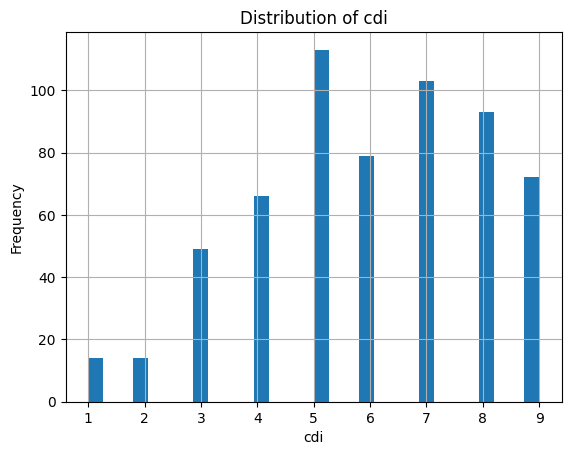

cdi skewness: -0.32333961422130675


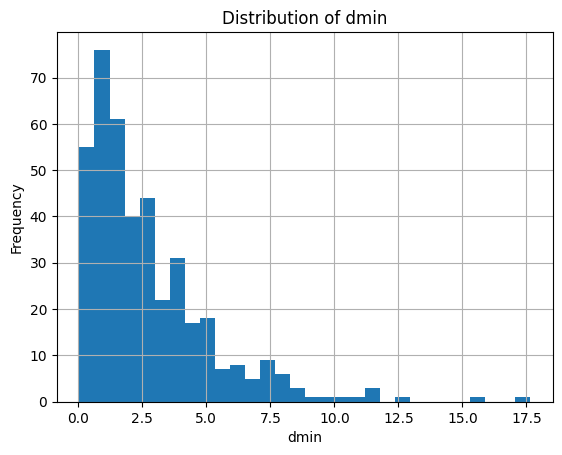

dmin skewness: 1.9997583308140012


In [9]:
import matplotlib.pyplot as plt

for col in ["cdi", "dmin"]:
    plt.figure()
    df[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

    print(f"{col} skewness:", df[col].skew())

### Imputation Decision

- **cdi** (skewness ≈ -0.32): distribution is roughly symmetric, so missing
  values will be imputed with the **mean**.
- **dmin** (skewness ≈ 2.00): distribution is strongly right-skewed with
  outliers, so missing values will be imputed with the **median**, which is
  more robust to extreme values.

10) Actually impute cdi and dmin: .fillna(value) replaces every NaN in that column with whatever value you give it — here, the column's own mean or median.

In [10]:
df["cdi"] = df["cdi"].fillna(df["cdi"].mean())
df["dmin"] = df["dmin"].fillna(df["dmin"].median())

print("Remaining missing in cdi:", df["cdi"].isnull().sum())
print("Remaining missing in dmin:", df["dmin"].isnull().sum())

Remaining missing in cdi: 0
Remaining missing in dmin: 0


11.Check skewness for gap and nst too:

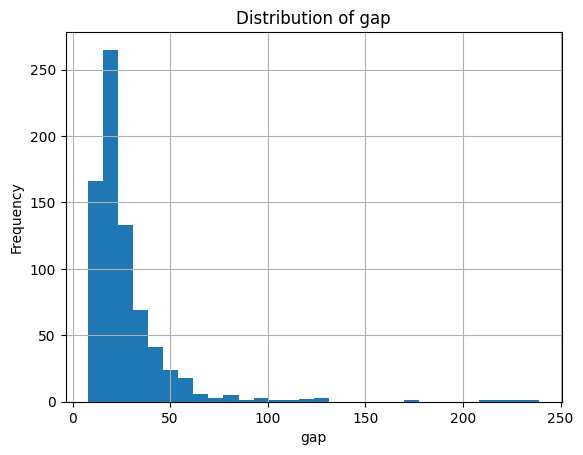

gap skewness: 4.885701324053703


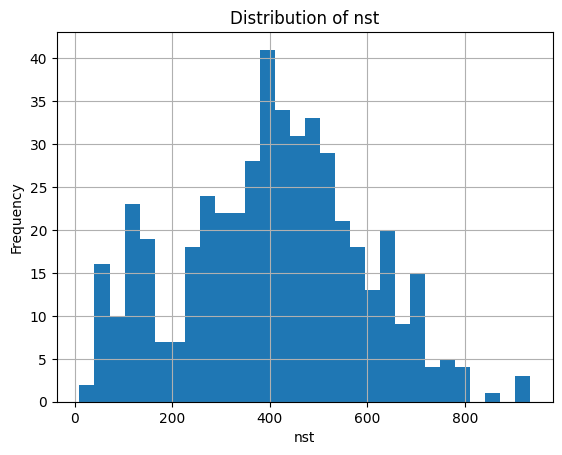

nst skewness: 0.007851413023867444


In [11]:
for col in ["gap", "nst"]:
    plt.figure()
    df[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

    print(f"{col} skewness:", df[col].skew())

- **gap** (skewness ≈ 4.89): heavily right-skewed, imputed with the **median**.
- **nst** (skewness ≈ 0.01): essentially symmetric, imputed with the **mean**.

In [12]:
df["gap"] = df["gap"].fillna(df["gap"].median())
df["nst"] = df["nst"].fillna(df["nst"].mean())

print("Remaining missing in gap:", df["gap"].isnull().sum())
print("Remaining missing in nst:", df["nst"].isnull().sum())

Remaining missing in gap: 0
Remaining missing in nst: 0


12) Handle the categorical/text columns

In [13]:
df["alert"] = df["alert"].fillna(df["alert"].mode()[0])

for col in ["continent", "country", "location"]:
    df[col] = df[col].fillna("Unknown")

print(df[["alert", "continent", "country", "location"]].isnull().sum())

alert        0
continent    0
country      0
location     0
dtype: int64


13) Confirm zero missing values across the whole table

In [14]:
print("Total missing values remaining:", df.isnull().sum().sum())

Total missing values remaining: 0


14) The final visualization:

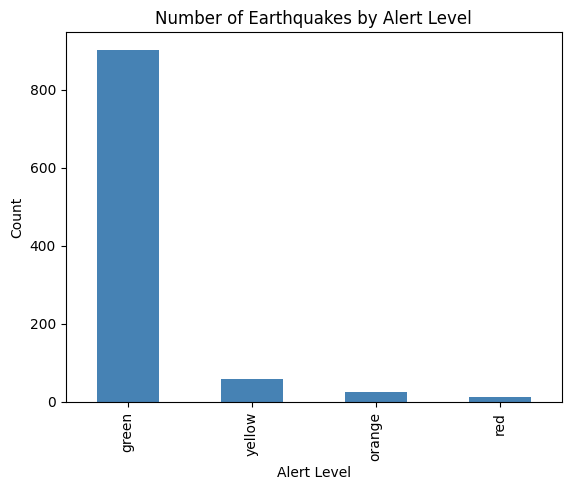

In [15]:
df["alert"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Number of Earthquakes by Alert Level")
plt.xlabel("Alert Level")
plt.ylabel("Count")
plt.show()

### Conclusion:

This lab assignment provided me hands-on experience with fundamental data analysis and visualization techniques using Python.
Key Learnings:
i) Data Preparation: Created and manipulated datasets, understanding the importance of clean, structured data for meaningful analysis.
ii) Statistical Analysis: Computed essential statistical measures including mean, median to derive insights from raw data.
iii) Data Visualization: Libraries like Matplotlib to transform numerical data into visual representations, making patterns and trends easily interpretable.
iv) Python Proficiency: Gained programming skills by working with core data structures like: lists, tuples, dictionaries, sets and powerful libraries like NumPy, Pandas.